# DS4DS Exercise Sheet 04

**General Instructions:**

- Review the weekly course material (lectures, readings, slides, etc.) before starting the exercises.
- Complete all assigned exercises independently before the Q&A session.
- Please use Julia Version 1.12.x to ensure compatibility.
- Please only write between the `#--- YOUR CODE STARTS HERE ---#` and `#--- YOUR CODE ENDS HERE ---#` comments.

### Task 1: Least Squares Linear Approximation

The measurements shown in the figure below were gathered from an unknown process.

<img src="measurements_updated.png" alt="measurements" width="400"/>

However, we can assume a linear relationship between the measurements $y$ and the inputs $u$ for the underlying process

$$
\begin{align}
    y[k] = w_0 + w_1 u[k]
\end{align}.
$$

Your task is to identify the parameter vector $$\boldsymbol{w} = \begin{bmatrix} w_0\\ w_1\end{bmatrix} $$ using the least squares approach shown in the lecture.

**Note:** You can solve this problem using either pen and paper or Julia. Place your calculated values for $w_0$ and $w_1$ into the variables below.

**Tip:** Think about the role of the two parameters you have acquired. Do they make sense for the data? Is there a way to visualize your result?

In [17]:
import numpy as np
### BEGIN SOLUTION
# 1. Define the input data (u) and measurements (y)
u = np.array([1, 2, 3])
y = np.array([2, 2, 4])

# 2. Set up the regression matrix (Phi)
# We need a column of 1s for the w_0 intercept, and a column of u values for w_1.
# np.ones(len(u)) creates an array of [1, 1, 1]
# np.column_stack stacks them side-by-side into a 2D matrix
Phi = np.column_stack((np.ones(len(u)), u))
print("Regression Matrix Phi:")
print(Phi)
print("-" * 30)

# 3. Solve using the Normal Equation
# In numpy, .T is the transpose, and @ performs matrix multiplication
Phi_T = Phi.T

# Step-by-step calculation mirroring the hand math:
# a) Calculate (Phi^T * Phi)
Phi_T_Phi = Phi_T @ Phi

# b) Calculate the inverse (Phi^T * Phi)^-1
Phi_T_Phi_inv = np.linalg.inv(Phi_T_Phi)

# c) Calculate Phi^T * y
Phi_T_y = Phi_T @ y

# d) Final parameter vector w
w = Phi_T_Phi_inv @ Phi_T_y

# --- Print the results ---
print("Parameter vector w:")
print(f"w_0 = {w[0]:.4f} (Theoretical: 2/3)")
print(f"w_1 = {w[1]:.4f} (Theoretical: 1)")

# ---------------------------------------------------------
# BONUS: The "Production" Way
# In real-world engineering, calculating the inverse directly is 
# computationally expensive and can be numerically unstable for huge matrices. 
# It is better to use NumPy's built-in least squares solver directly on Phi and y!
# 
# w_fast, residuals, rank, s = np.linalg.lstsq(Phi, y, rcond=None)
# print(w_fast)
# ---------------------------------------------------------

### END SOLUTION

Regression Matrix Phi:
[[1. 1.]
 [1. 2.]
 [1. 3.]]
------------------------------
Parameter vector w:
w_0 = 0.6667 (Theoretical: 2/3)
w_1 = 1.0000 (Theoretical: 1)


### Task 2: Parameter Estimation of the DC Motor

The electrical behaviour of the DC motor in steady state is characterized by the following static equation

$$
\begin{align}
    i_s = u_s \frac{1}{R_s} - \omega \frac{\Psi_E}{R_s}
\end{align}
$$

where $u_s$ is the voltage provided by a power supply, $\omega$ is the rotation speed which is set by a mechanical load machine, $R_s$ and $\Psi_E$ are unknown values and $i_s$ is the current that can be measured after the motor reached steady-state operation. For the whole task, you can assume that $u_s$ and $\omega$ are perfectly known, while the measured values for $i_s$ are affected by bias-free, additive, Gaussian noise.

**a)** Consider the system described above. Assign each of the equation components to the different elements of the least squares problem. For this, map each of the components in the cell below to one of the following classes: 
- class **1**: Measurements $\boldsymbol{y}$
- class **2**: Regressors $\boldsymbol{z}$
- class **3**: Parameters $\boldsymbol{w}$ (this is the letter $\boldsymbol{w}$ for the parameter vector not to be confused with the greek symbol $\omega$ for the angular velocity)

In [18]:
# choose 1,2 or 3

class_i_s = 1
class_u_s = 2
class_one_over_R_s = 3  # i.e. 1/R_s
class_omega = 2
class_minus_Psi_E_over_R_s = 3  # i.e. - Psi_E/R_s

### BEGIN SOLUTION

### END SOLUTION

**b)** Implement the function below to calculate the parameters $\boldsymbol{w}$ from the regressor matrix $\boldsymbol{Z}$ and the measurement vector $\boldsymbol{y}$ using the ordinary least squares approach from the lecture. 

**Hint**: This is not specific to the system at hand.

In [19]:
def parameter_calculation_OLS(Z, y):
    """
    Args:
        Z: regressor matrix with shape (n_measurements, n_regressors)
        y: measurement_vector with shape (n_measurements)
        
    Returns:
        The parameter vector w with shape (n_parameters)
    """
    
    ### BEGIN SOLUTION
    
    # In numpy:
    # .T gives the transpose of the matrix
    # @ performs matrix multiplication (dot product)
    # np.linalg.inv() calculates the matrix inverse
    
    Z_transpose = Z.T
    
    # Calculate (Z^T * Z)^-1
    inverse_term = np.linalg.inv(Z_transpose @ Z)
    
    # Calculate Z^T * y
    product_term = Z_transpose @ y
    
    # Combine them to solve for w
    w = inverse_term @ product_term
    
    # Alternatively, you can write it entirely on one line:
    # w = np.linalg.inv(Z.T @ Z) @ Z.T @ y
    
    ### END SOLUTION
    
    return w

**c)** Use the function implemented in subtask b) and the given data for $u_s$, $\omega$ and $i_s$ to estimate values for $a = \frac{1}{R_s}$ and $b = -\frac{\Psi_E}{R_s}$. Put your results for $a$ and $b$ into the variables below.

In [20]:
import scipy.io

# Load the MATLAB file using scipy
data_task_2 = scipy.io.loadmat("data_task_2.mat")

# Extract the arrays and use .flatten() to ensure they are 1D vectors 
# (MATLAB files often load as 2D column arrays by default in Python)
u_s = data_task_2["u_s"].flatten()
omega = data_task_2["omega"].flatten()
i_s = data_task_2["i"].flatten()

In [21]:
### BEGIN SOLUTION
Z=np.column_stack((u_s, omega))
y=i_s
w = parameter_calculation_OLS(Z, y)
a=w[0]  # This is the parameter corresponding to u_s
b=w[1]  # This is the parameter corresponding to omega
### END SOLUTION

**d)** Implement a function to compute estimations for $R_s$ and $\Psi_E$ based on $a$ and $b$.

In [22]:
def compute_Rs_Psi_E(a, b):

    ### BEGIN SOLUTION
    R_s=1/a
    Psi_E=-b*R_s
    ### END SOLUTION

    return R_s, Psi_E

**e)** Analyse the accuracy of your parameter estimates. For this, take into consideration that the measured values for $i_{s}$, that you loaded from the file, are affected by bias-free, additive, Gaussian noise:

$$
\begin{align}
i_{s} = i_{s, true} + \nu \quad \mathrm{with} \, \nu \sim \mathcal{N}(0, \sigma_n^2).
\end{align}
$$

i) Estimate the corrected sample variance of $\nu$ from the measurements for $i_s$, that you were given, and your estimate $\hat{i}_s$, that is based on the estimated parameters.

In [23]:
### BEGIN SOLUTION

# 1. Calculate the estimated current (i_s_hat) using your parameter vector w
i_s_hat = Z @ w

# 2. Calculate the residuals (the estimated noise nu)
nu_hat = i_s - i_s_hat

# 3. Determine the degrees of freedom (N - p)
# N = number of measurements (rows in Z)
# p = number of estimated parameters (columns in Z)
N = Z.shape[0]
p = Z.shape[1]
dof = N - p

# 4. Calculate the corrected sample variance
# Sum of squared residuals divided by degrees of freedom
#You can think of this as the quantification of the "spread" in the dataset
var_nu = np.sum(nu_hat**2) / dof

### END SOLUTION

print(f"Estimated noise variance (var_nu): {var_nu}")

Estimated noise variance (var_nu): 2.7791187830158073


ii) Implement the function below to estimate the covariance matrix of the parameter vector $\boldsymbol{w}$ based on the noise variance $\sigma_n^2$ and the regressor matrix $\boldsymbol{Z}$ 

$$\text{Cov}(\boldsymbol{w}) = \begin{bmatrix} \text{Var}(a) & \text{Cov}(a, b) \\ \text{Cov}(b, a) & \text{Var}(b) \end{bmatrix}$$

1. The Main Diagonal (The Variances)

. Top-Left ($\text{Var}(a)$): This is the variance of your first parameter ($a = 1/R_s$). It tells you how much your estimate of $a$ would bounce around if you repeated this exact experiment $100$ times with new noisy data. A larger number means you are highly uncertain about the true value of $R_s$. <br>
. Bottom-Right ($\text{Var}(b)$): This is the variance of your second parameter ($b = -\Psi_E/R_s$). It tells you the uncertainty specifically for $b$. <br>

2. The Off-Diagonals (The Covariances)<br>

. $\text{Cov}(a, b)$ and $\text{Cov}(b, a)$: These two numbers are identical. They tell you how the errors in your estimates are linked.<br>
     . If this number is positive, it means if the noise tricked your model into estimating an $a$ that is too high, it probably also estimated a $b$ that is too high.<br>
    . If this number is negative, it means overestimating $a$ usually results in underestimating $b$.<br>

$$\text{Cov}(\boldsymbol{w}) = \sigma_n^2 (\boldsymbol{Z}^T \boldsymbol{Z})^{-1}$$

In [24]:
def estimate_covariance_matrix(var_nu, Z):
    """
    You can think of this matrix as the "Matrix of Uncertainty." 
    It tells you exactly how much confidence you should have in the parameters your model just calculated.
    Args:
        var_nu: variance of the noise process (scalar)
        Z: regressor matrix with shape (n_measurements, n_regressors)
        
    Returns:
        cov_w: covariance matrix of parameter vector w
    """
    
    ### BEGIN SOLUTION
    
    # Calculate the (Z^T * Z)^-1 term
    Z_transpose = Z.T
    inverse_term = np.linalg.inv(Z_transpose @ Z)
    
    # Multiply by the noise variance scalar
    #depends on the noise variance (sensor quality) 
    # and the geometry of the data (Z) (quality of the data - low speed and low voltage, high value and diverse speed and voltage - low value == highly confident estimate)
    cov_w = var_nu * inverse_term 
    ### END SOLUTION
    
    return cov_w

# --- Test it out ---
# cov_matrix = estimate_covariance_matrix(var_nu, Z)
# print("Covariance Matrix of w:\n", cov_matrix)

iii) Evaluate the coefficient of determination for the regression problem (see https://en.wikipedia.org/wiki/Coefficient_of_determination).

$$
\begin{align}
    R^2 = 1 - \frac{\sum_i{(y_i - \hat{y}_i)^2}}{\sum_i{(y_i - \bar{y})^2}}
\end{align}
$$

The Math: Understanding $R^2$ <br>
The $R^2$ score is a statistical measure that tells you how well your model's predictions fit the real data. It acts as a "grade" for your regression model, usually falling between $0$ and $1$ (or $0\%$ to $100\%$). <br>
To calculate it, the formula compares two different errors: <br>
1. The Numerator ($\sum(y_i - \hat{y}_i)^2$): This is the Sum of Squared Residuals (SSR). It measures the error of your specific model (how far the data is from your calculated line). <br>
2. The Denominator ($\sum(y_i - \bar{y})^2$): This is the Total Sum of Squares (SST). It measures the error of the "dumbest" possible model—a completely flat line drawn exactly at the average ($\bar{y}$) of your data. <br>

By dividing your model's error by the "dumb" model's error and subtracting from 1, you find out exactly what percentage of the data's behavior is successfully explained by your DC motor equation.


In [25]:
### BEGIN SOLUTION

# 1. Calculate the mean of the actual measurements (y_bar)
i_s_mean = np.mean(i_s)

# 2. Calculate the Total Sum of Squares (denominator)
SST = np.sum((i_s - i_s_mean)**2)

# 3. Calculate your model's predictions (y_hat)
# (If you already have i_s_hat from the previous cell, you can reuse it)
i_s_hat = Z @ w

# 4. Calculate the Sum of Squared Residuals (numerator)
SSR = np.sum((i_s - i_s_hat)**2)

# 5. Calculate final R^2 score
R_squared = 1 - (SSR / SST)

### END SOLUTION

print(f"Coefficient of Determination (R^2): {R_squared:.4f}")

Coefficient of Determination (R^2): 0.9827


### Task 3: Estimate Polynom Coefficients

The given data was produced using a polynomial of the form


$$
\begin{align}
    y = w_0 + x \cdot w_1 + \dots + x^p \cdot w_p
\end{align}
$$

with an unknown degree $p$.

Below you are given data for the inputs $x$ and the outputs $y$. On the one hand you are given training data you will use for the identification of coefficients (estimation of a model) and validation data
that is used to evaluate the generalization performance of your model. All of the data for the measurements $y$ is affected by bias-free, additive, Gaussian noise, i.e., the values you are given below do not fully follow the formula given above, but instead

$$
\begin{align}
    y = w_0 + x \cdot w_1 + \dots + x^p \cdot w_p + \nu \quad \mathrm{with} \, \nu \sim \mathcal{N}(0, \sigma_n^2).
\end{align}
$$

The variance of the noise process is unknown, but it is also not necessary to estimate it for completing this task.

In [26]:
# Load the MATLAB file using scipy
data_task_3 = scipy.io.loadmat("data_task_3.mat")

In [27]:
u_s = data_task_2["u_s"].flatten()
omega = data_task_2["omega"].flatten()
i_s = data_task_2["i"].flatten()
# training data
x_training = data_task_3["x_training"].flatten()
y_training = data_task_3["y_training"].flatten()

# validation data
x_validation = data_task_3["x_validation"].flatten()
y_validation = data_task_3["y_validation"].flatten()

**a)** Consider the regression problem of the form:

$$
\begin{align}
    \boldsymbol{y} = \boldsymbol{Z} \cdot \boldsymbol{w}  + \boldsymbol{\nu}.
\end{align}
$$

Implement the function below to compute the regressor matrix $\boldsymbol{Z}$ for the polynom coefficient estimation problem described above. The function takes the input data $\boldsymbol{x}$ and the degree of the polynom $p$ as inputs.

**Example:** If $p=2$, we get a model until the 2nd polynomial degree

$$
\begin{align}
    y = w_0 + x \cdot w_1 + x^2 \cdot w_2
\end{align}
$$

which results in the regressor vector

$$
\begin{align}
    \boldsymbol{z} = \begin{bmatrix} 1 & x & x^2 \end{bmatrix}.
\end{align}
$$

With an input vector $\boldsymbol{x} = \begin{bmatrix} 1 & 2 & 3 \end{bmatrix}$ this results in the regressor matrix

$$
\begin{align}
    \boldsymbol{Z} = \begin{bmatrix}
        1 & 1 & 1 \\
        1 & 2 & 4 \\
        1 & 3 & 9 \\
    \end{bmatrix}.
\end{align}
$$



In [28]:
def regressor_matrix(x, p):
    """
    Args:
        x: Input data (1D array-like)
        p: Degree of the polynomial
        
    Returns:
        Regressor matrix Z with shape (len(x), p+1)
    """
    # Ensure x is a numpy array so we can easily apply powers to it
    x = np.array(x)
    
    ### BEGIN SOLUTION
    
    # We will build the matrix column by column.
    # range(p + 1) generates numbers from 0 up to exactly p.
    # We create a list of arrays: [x**0, x**1, x**2, ..., x**p]
    columns = [x**i for i in range(p + 1)]
    
    # np.column_stack takes that list of 1D columns and binds them 
    # together side-by-side into a single 2D matrix.
    Z = np.column_stack(columns)
    
    ### END SOLUTION
    
    return Z

# --- Test the Example ---
# x_example = [1, 2, 3]
# p_example = 2
# print(regressor_matrix(x_example, p_example))

**b)** Write the computation of the parameter estimation using OLS as a function of the input data $\boldsymbol{x}$, the output data $\boldsymbol{y}$ and the degree of the polynomial $p$. Your goal is to find the parameters $\boldsymbol{w}$ for the polynom of degree $p$. Use the function for the computation of the regression matrix that was asked for in subtask a)

In [29]:
import numpy as np

def compute_parameter_estimation(x, y, p):
    """
    Args:
        x: Input data
        y: Output data
        p: Degree of the polynomial
        
    Returns:
        parameter vector w with shape (p+1)
    """
    
    ### BEGIN SOLUTION
    
    # 1. Compute the regressor matrix Z using your function from subtask a
    Z = regressor_matrix(x, p)
    
    # 2. Compute the parameter vector w using the Normal Equation
    # Formula: w = (Z^T * Z)^-1 * Z^T * y
    Z_transpose = Z.T
    
    inverse_term = np.linalg.inv(Z_transpose @ Z)
    product_term = Z_transpose @ y
    
    w = inverse_term @ product_term
    
    # Note: If your environment still has the function from your DC Motor task 
    # loaded in memory, you could also just write:
    # w = parameter_calculation_OLS(Z, y)
    
    ### END SOLUTION
    
    return w

**c)** Your goal now is to find the fit onto the training data that best generalizes to the validation data.

For this:
- iterate over the degree of the polynomial $p$,
- find the parameter vector $\boldsymbol{w}_p$ based on the training data $\boldsymbol{x}_{training}$ and $\boldsymbol{y}_{training}$,
- compute the estimates $\hat{\boldsymbol{y}}$ using $\boldsymbol{w}_p$ and $\boldsymbol{x}_{validation}$, and
- compare the estimates $\hat{\boldsymbol{y}}$ with $\boldsymbol{y}_{validation}$ using the given error function.

In [30]:
# 1. Define the error function
def error_function(a, b):
    """Computes the root mean square error between two input vectors."""
    # Equivalents of Julia's @assert macros
    assert len(a) == len(b), "Vectors must be of the same length"
    assert a.ndim == 1 and b.ndim == 1, "Vectors must be 1-dimensional"
    
    N = len(a)
    return np.sqrt((1/N) * np.sum((a - b)**2))

# ---------------------------------------------------------

# Assuming x_training, y_training, x_validation, and y_validation 
# are already loaded in your notebook workspace.

### BEGIN SOLUTION

# Define a reasonable range of polynomial degrees to test 
# (e.g., from a flat line p=1 up to a highly complex curve p=10)
max_degree = 10 

best_p = -1
lowest_error = float('inf')

for p in range(1, max_degree + 1):
    
    # Step A: Find parameter vector w_p based on the TRAINING data
    w_p = compute_parameter_estimation(x_training, y_training, p) #w_p from training data
    
    # Step B: Compute estimates y_hat using w_p and the VALIDATION data
    # We must build a new regressor matrix specifically for the validation inputs!
    Z_validation = regressor_matrix(x_validation, p) #regressor matrix for validation data
    y_hat = Z_validation @ w_p #predicted outputs for validation data using the model trained on training data
    
    # Step C: Compare estimates with y_validation using the error function
    current_validation_error = error_function(y_hat, y_validation)
    
    # Keep track of the best-performing model
    if current_validation_error < lowest_error:
        lowest_error = current_validation_error
        best_p = p

### END SOLUTION

print(f"The model that best generalizes is degree p = {best_p}")
print(f"Validation Error (RMSE): {lowest_error:.4f}")

The model that best generalizes is degree p = 4
Validation Error (RMSE): 7.2482


Find a polynomial model with **an error below $10$** according to the steps described above and report its degree in the variable $p_{sol}$ below. 

**Hint 1:** $p_{sol} \in [0, 10]$

**Hint 2:** Multiple degrees for the polynomial produce an error that is low enough. 

In [31]:
### BEGIN SOLUTION
p_sol = -1

# range(11) iterates from 0 up to 10
for p in range(11): 
    # 1. Train the model using the training data
    w_p = compute_parameter_estimation(x_training, y_training, p)
    
    # 2. Generate predictions using the validation data
    Z_val = regressor_matrix(x_validation, p)
    y_hat = Z_val @ w_p
    
    # 3. Calculate the validation error
    err = error_function(y_hat, y_validation)
    
    # 4. Check if we hit the target
    if err < 10:
        p_sol = p
        break  # We found a valid degree, so we can stop searching

### END SOLUTION

print(f"A polynomial of degree p_sol = {p_sol} produces an error below 10.")

A polynomial of degree p_sol = 3 produces an error below 10.


Plot the estimates of the model, the training data and the validation data for each value of $p \in [0, 10]$. Why is the highest degree of freedom not necessarily the best choice? What effect that you might know from the context of machine learning can be seen here?

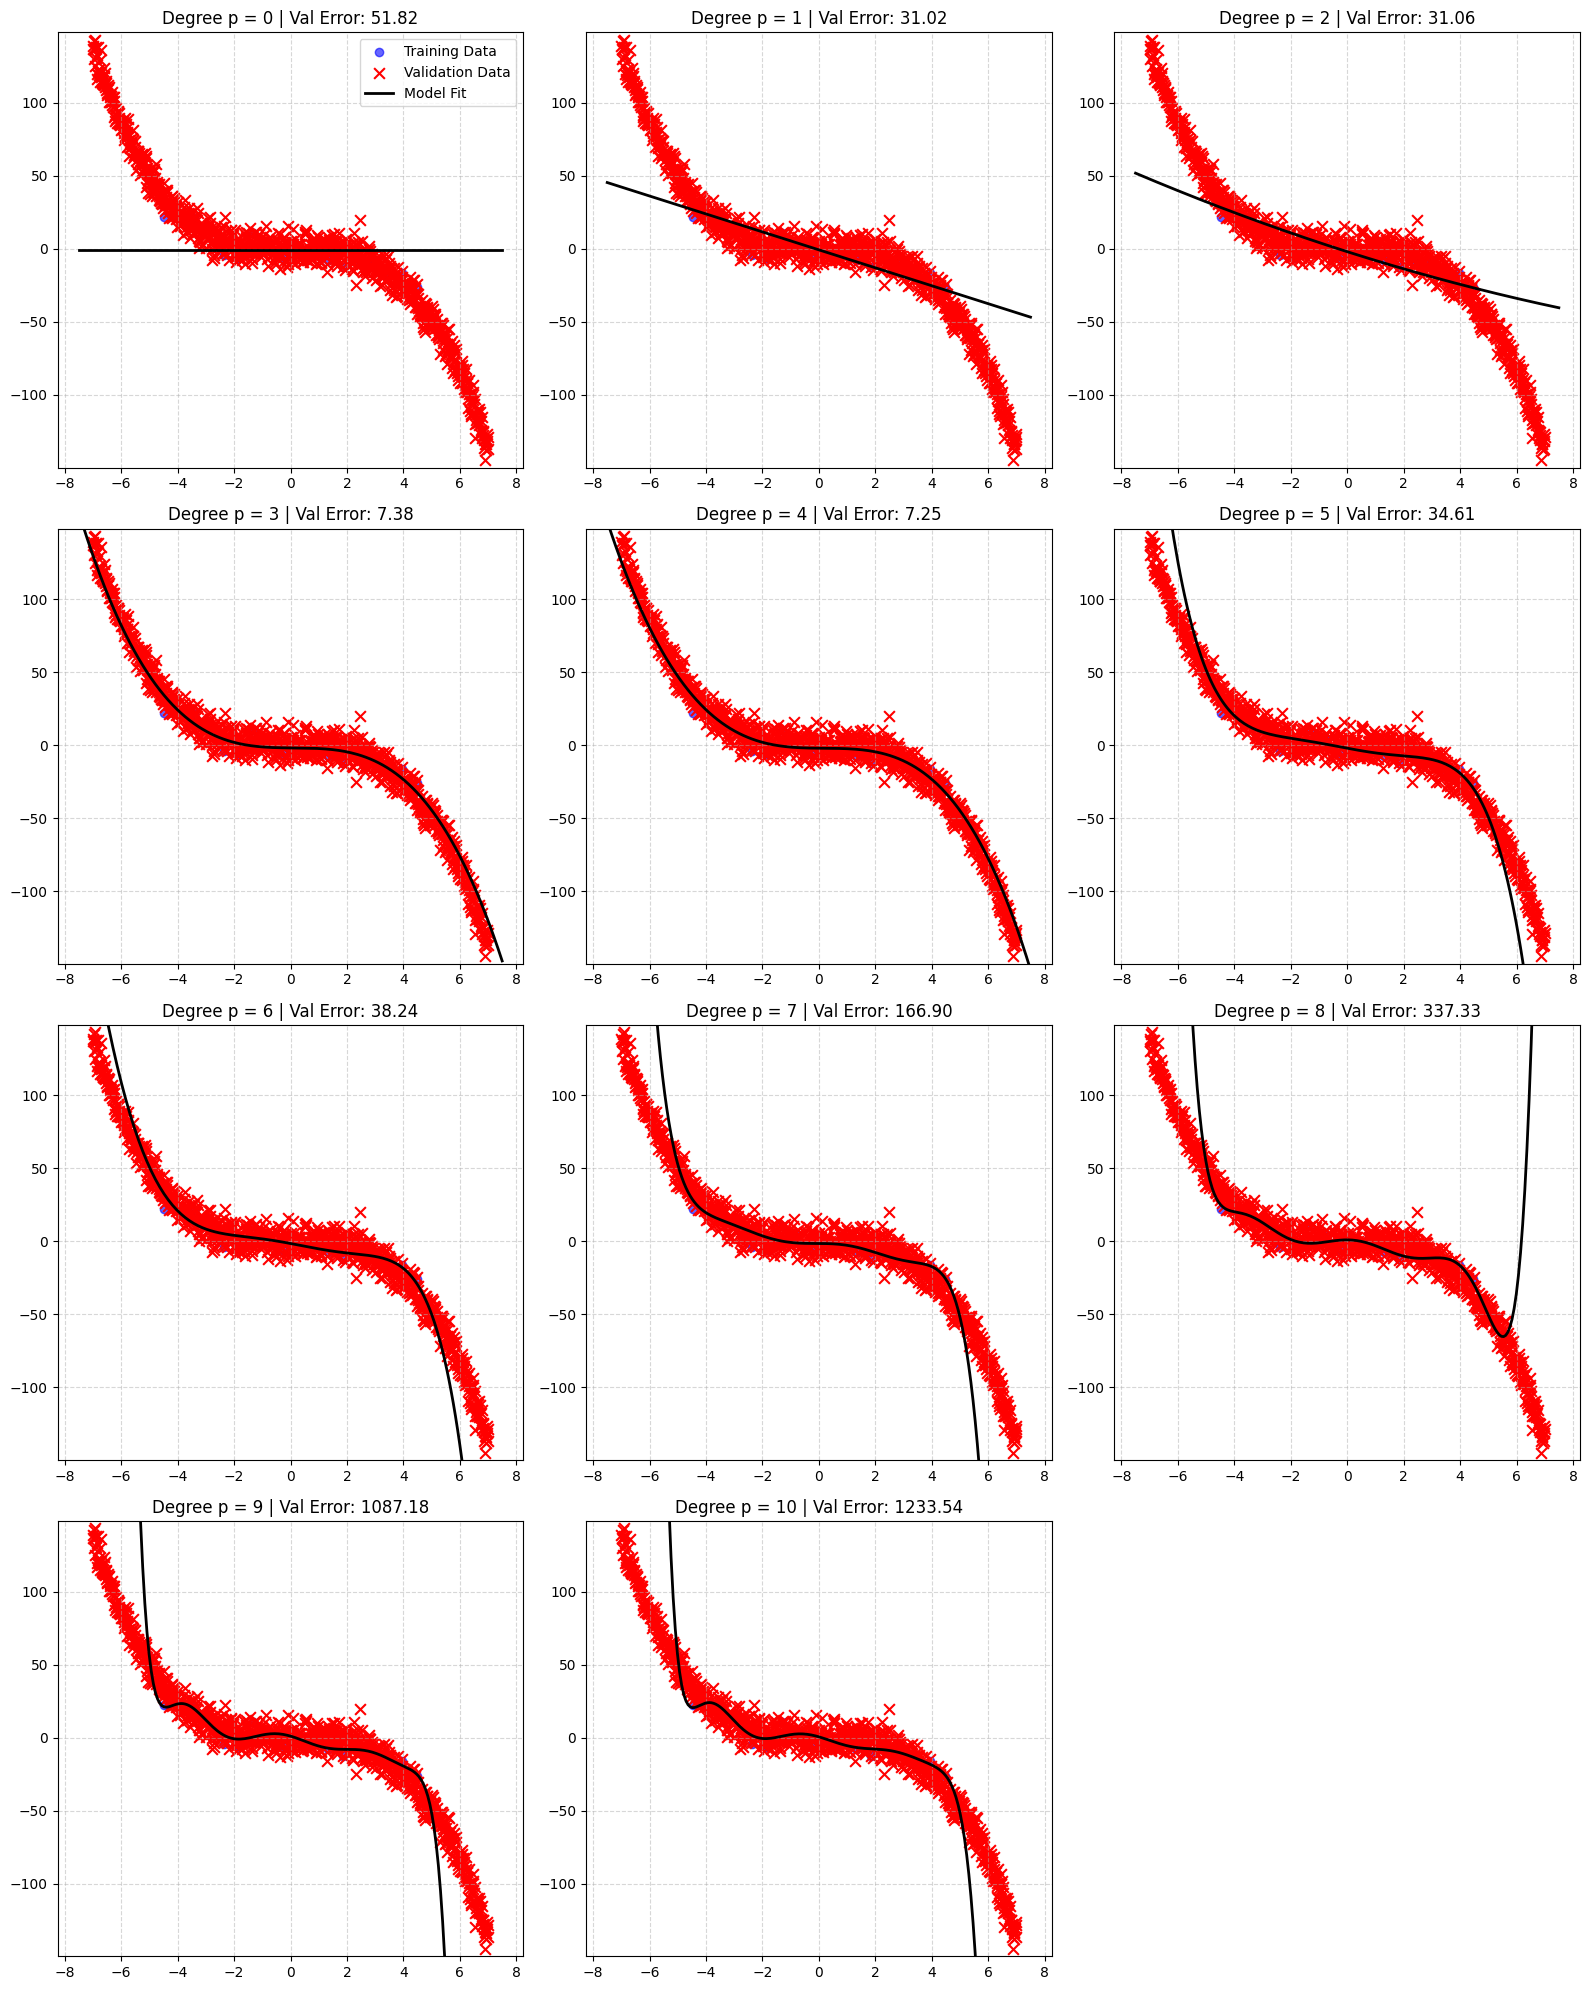

In [ ]:
#Highest degree polynomial not necessarily the best choice because it may overfit the training data and perform poorly on unseen data (validation set).

import matplotlib.pyplot as plt
import numpy as np

# 1. Setup the figure and a grid of subplots (4 rows, 3 columns = 12 total spots)
# figsize determines the overall width and height of the image
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(16, 20))

# Flatten the 2D grid of axes into a 1D list so we can easily loop through it
axes = axes.flatten()

# 2. Create a dense, smooth array of x-values for drawing the continuous curve
# If we only plot our model at the training points, the line will look jagged.
x_min = min(np.min(x_training), np.min(x_validation))
x_max = max(np.max(x_training), np.max(x_validation))
x_smooth = np.linspace(x_min - 0.5, x_max + 0.5, 200)

### BEGIN PLOTTING LOOP

for p in range(11): # Loops from 0 to 10
    ax = axes[p]
    
    # --- Model Calculations ---
    # Calculate the parameters
    w_p = compute_parameter_estimation(x_training, y_training, p)
    
    # Calculate the continuous model curve for plotting
    Z_smooth = regressor_matrix(x_smooth, p)
    y_smooth = Z_smooth @ w_p
    
    # Calculate the validation error to display in the title
    Z_val = regressor_matrix(x_validation, p)
    y_hat = Z_val @ w_p
    err = error_function(y_hat, y_validation)
    
    # --- Plotting the Data ---
    # Plot Training data (Blue dots)
    ax.scatter(x_training, y_training, color='blue', alpha=0.6, label='Training Data')
    
    # Plot Validation data (Red X's)
    ax.scatter(x_validation, y_validation, color='red', marker='x', s=60, label='Validation Data')
    
    # Plot the Model's curve (Black line)
    ax.plot(x_smooth, y_smooth, color='black', linewidth=2, label=f'Model Fit')
    
    # --- Formatting the Subplot ---
    ax.set_title(f'Degree p = {p} | Val Error: {err:.2f}')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # **CRITICAL: Lock the Y-axis limits**
    # High-degree polynomials (like p=9 or 10) can shoot off to infinity between points.
    # If we don't lock the axis, the chart will zoom way out and the data will be invisible.
    y_min_lim = min(np.min(y_training), np.min(y_validation))
    y_max_lim = max(np.max(y_training), np.max(y_validation))
    ax.set_ylim(y_min_lim - 5, y_max_lim + 5)
    
    # Add a legend, but only to the very first plot so it doesn't get repetitive
    if p == 0:
        ax.legend()
### END PLOTTING LOOP

# We created 12 subplots but only used 11 (0 through 10). 
# This hides the empty 12th box in the bottom right corner.
axes[-1].axis('off')

# Automatically adjust spacing so titles and labels don't overlap
plt.tight_layout()

# Render the plot to the screen
plt.show()